# Computer Vision - Project 1

This notebook runs three parts: RGB channels, spatial filters, and geometric transforms. The functions are imported from `src/`.

## Setup

Install dependencies from the repository root with `python -m pip install -r requirements.txt`.

For Google Colab, run `!git clone -b Project_1 --single-branch https://github.com/nghoang1162050/CO3057-BTL_17.git`, then `%cd CO3057-BTL_17`, then `!pip install -r requirements.txt` before running this notebook.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "src").is_dir():
    repo_root = repo_root.parent
if not (repo_root / "src").is_dir():
    raise FileNotFoundError("Open this notebook from the repository root or notebooks/ directory")
sys.path.insert(0, str(repo_root / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from utils import add_gaussian_noise, load_sample_images, to_gray3
import part1_color_channels as p1
import part2_filtering as p2
import part3_transformations as p3

images = load_sample_images()
print(list(images))

['astronaut', 'checkerboard', 'coins', 'camera']


The examples use sample images bundled with `scikit-image`, so no separate image files are needed.

## Part 1 - Color channels

Grayscale uses $Y = 0.299R + 0.587G + 0.114B$. It keeps brightness but loses color. Splitting and joining RGB channels keeps the original image exactly.

max |manual - cv2| = 1


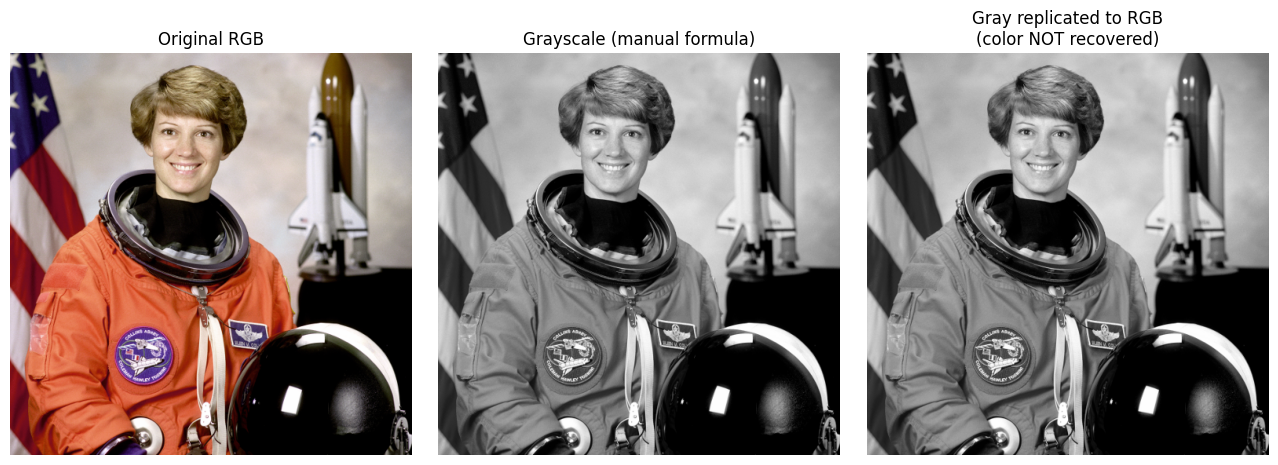

In [2]:
img = images["astronaut"]

gray_manual = p1.rgb_to_gray_manual(img)
gray_cv2 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
print("max |manual - cv2| =", int(np.max(np.abs(gray_manual.astype(int) - gray_cv2.astype(int)))))

gray_back_to_rgb = p1.gray_to_rgb_replicated(gray_manual)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, im, t in zip(axes, [img, to_gray3(gray_manual), gray_back_to_rgb],
                      ["Original RGB", "Grayscale (manual formula)", "Gray replicated to RGB\n(color NOT recovered)"]):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

Reconstruction identical to original: True


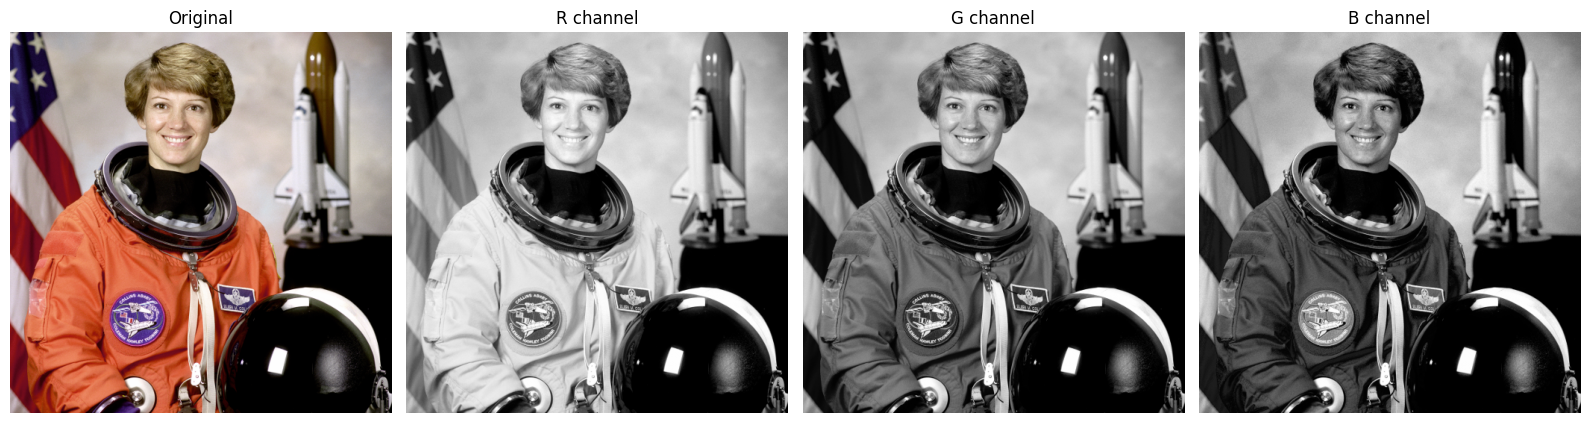

In [3]:
r, g, b = p1.split_channels(img)
reconstructed = p1.reconstruct_from_channels(r, g, b)
print("Reconstruction identical to original:", np.array_equal(reconstructed, img))

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, im, t in zip(axes, [img, r, g, b], ["Original", "R channel", "G channel", "B channel"]):
    ax.imshow(im, cmap=("gray" if im.ndim == 2 else None)); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

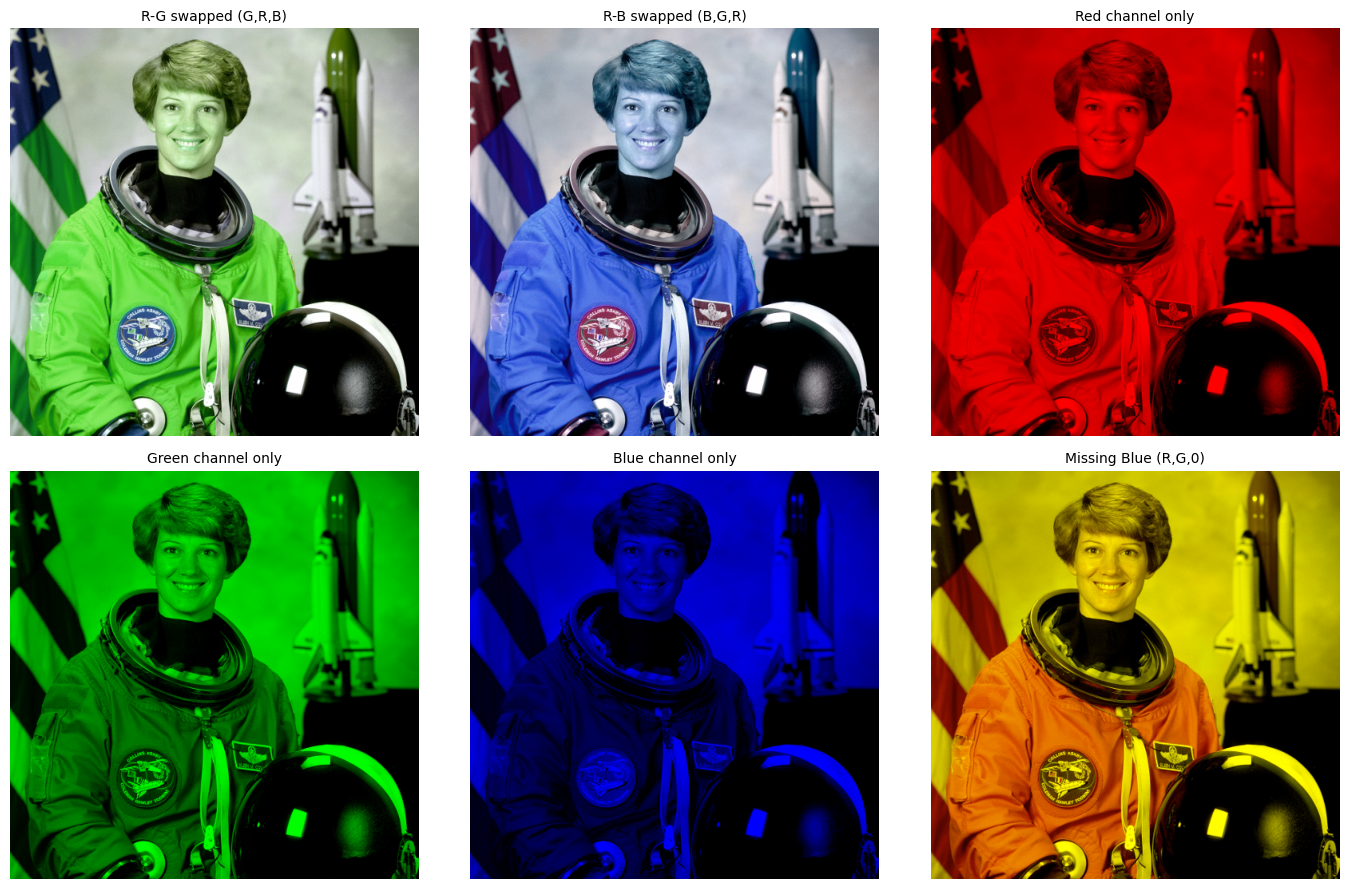

In [4]:
variants = p1.make_swapped_variants(img)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (name, im) in zip(axes.ravel(), variants.items()):
    ax.imshow(im); ax.set_title(name, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

**Observation:** Each channel shows different details. Swapping channels changes colors; removing one loses its color information.

## Part 2 - Spatial filtering

Mean and Gaussian filters smooth noise and edges. Laplacian and Sobel show intensity changes. The custom kernel sharpens details but can also strengthen noise.

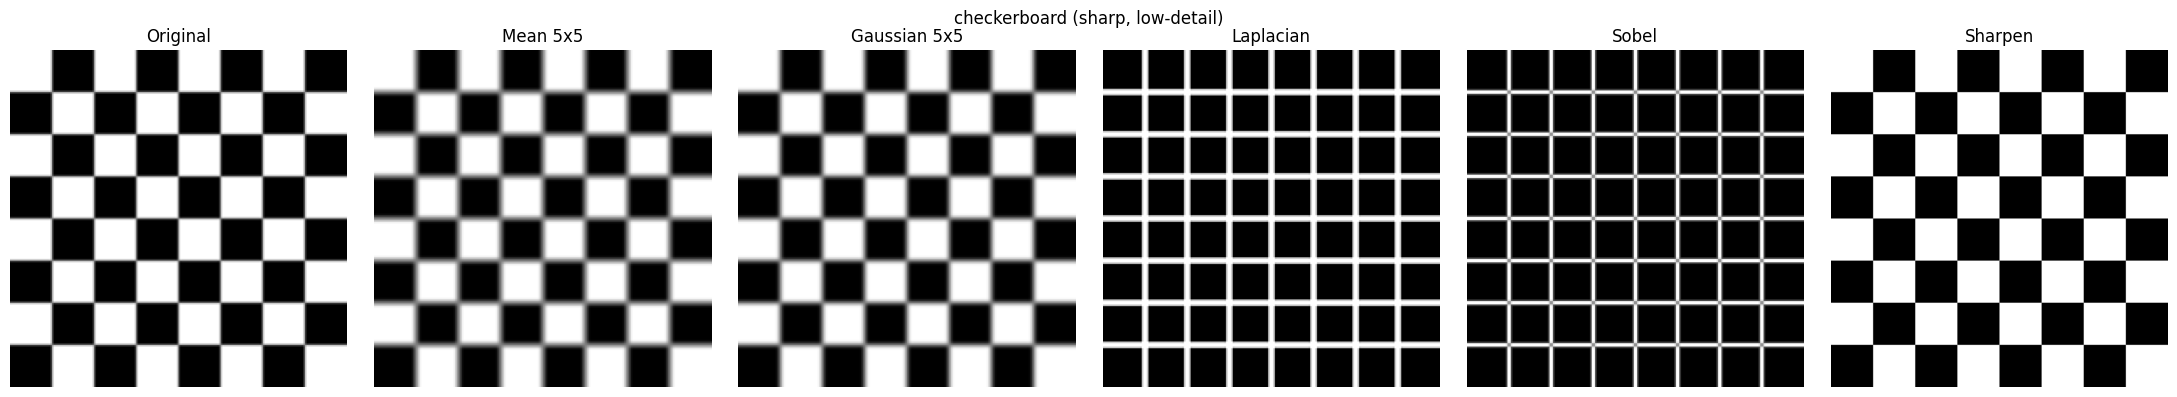

checkerboard (sharp, low-detail): residual std = 44.70 (original), 28.51 (mean), 31.44 (Gaussian)


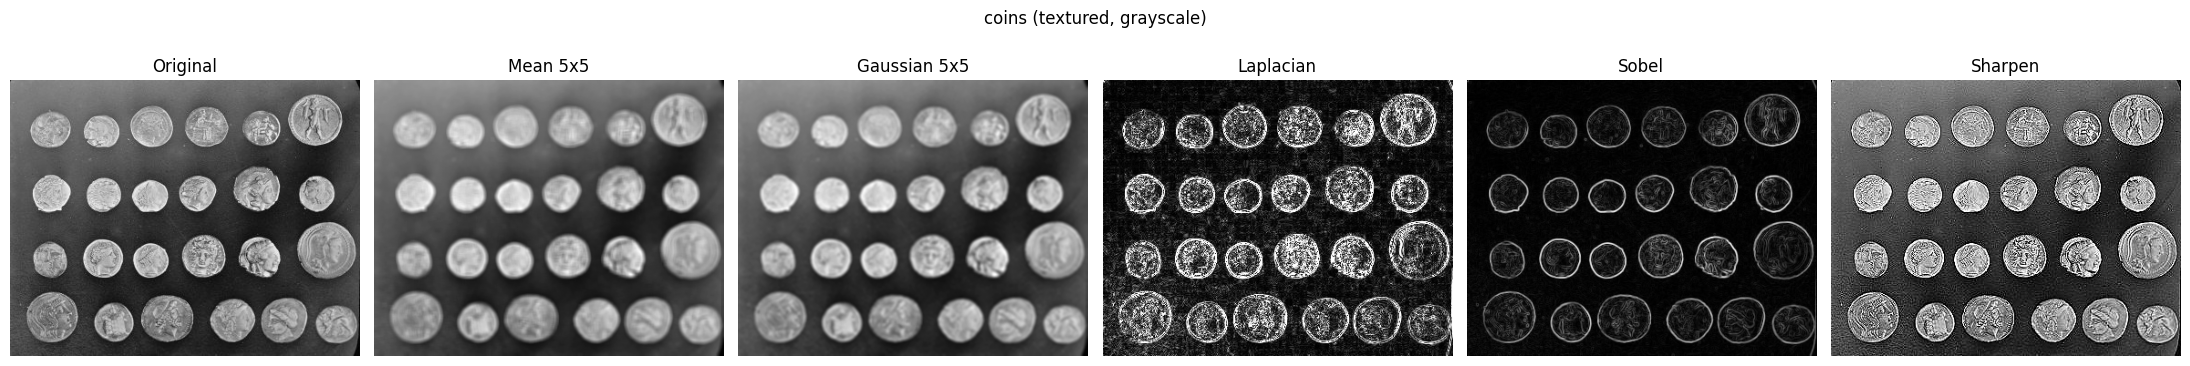

coins (textured, grayscale): residual std = 20.19 (original), 9.97 (mean), 11.28 (Gaussian)


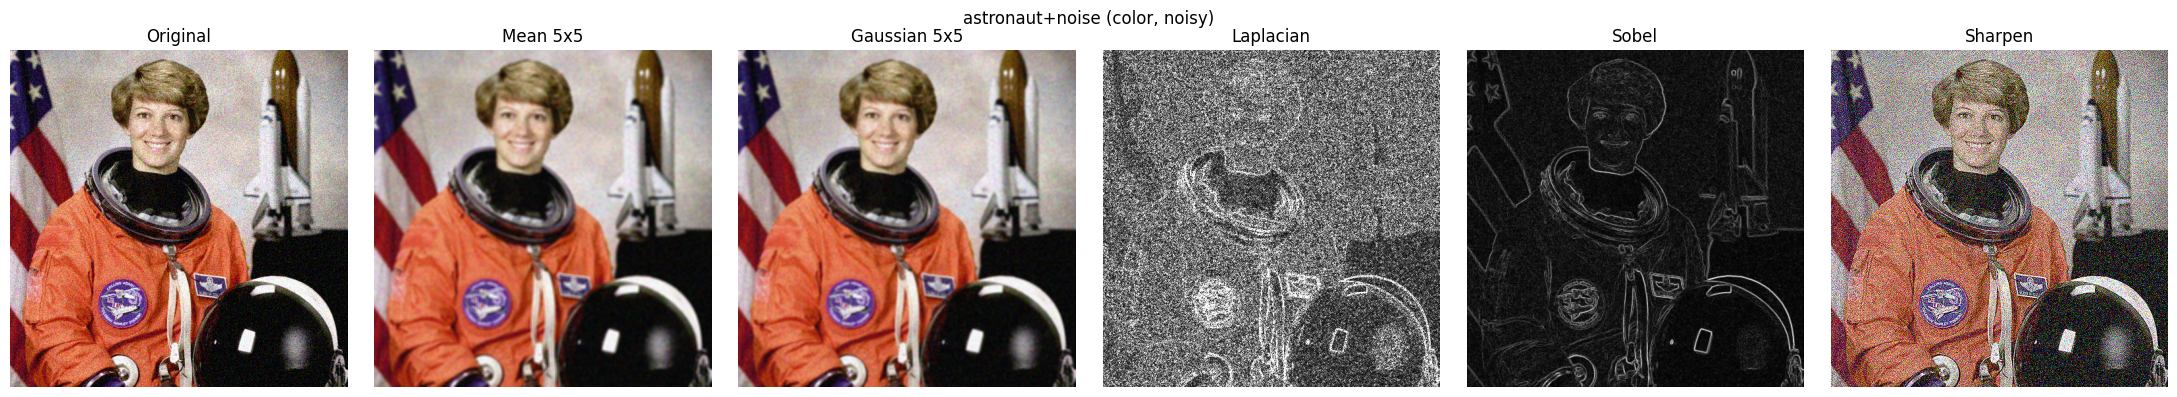

astronaut+noise (color, noisy): residual std = 23.19 (original), 10.47 (mean), 11.66 (Gaussian)


In [5]:
test_cases = {
    "checkerboard (sharp, low-detail)": images["checkerboard"],
    "coins (textured, grayscale)": images["coins"],
    "astronaut+noise (color, noisy)": add_gaussian_noise(images["astronaut"], sigma=25),
}

for name, im in test_cases.items():
    gray = p2.to_gray(im)
    mean5 = p2.mean_filter(im, 5)
    gauss5 = p2.gaussian_filter(im, 5, 1.5)
    lap = p2.laplacian_filter(gray)
    sob = p2.sobel_filter(gray)
    sharp = p2.custom_sharpen_filter(im)

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    titles = ["Original", "Mean 5x5", "Gaussian 5x5", "Laplacian", "Sobel", "Sharpen"]
    for ax, result, title in zip(axes, [im, mean5, gauss5, lap, sob, sharp], titles):
        ax.imshow(result, cmap="gray" if result.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(name)
    plt.tight_layout()
    plt.show()

    print(f"{name}: residual std = {p2.noise_std(im):.2f} (original), "
          f"{p2.noise_std(mean5):.2f} (mean), {p2.noise_std(gauss5):.2f} (Gaussian)")

**Observation:** Smoothing lowers the residual standard deviation, but this measure includes real edges as well as noise. High-pass filters show edges clearly on the checkerboard and also show noise in the astronaut image.

## Part 3 - Geometric transforms

Translation, rotation, and scaling change the image position, angle, or size. An affine transform keeps parallel lines parallel. A projective transform can make them converge.

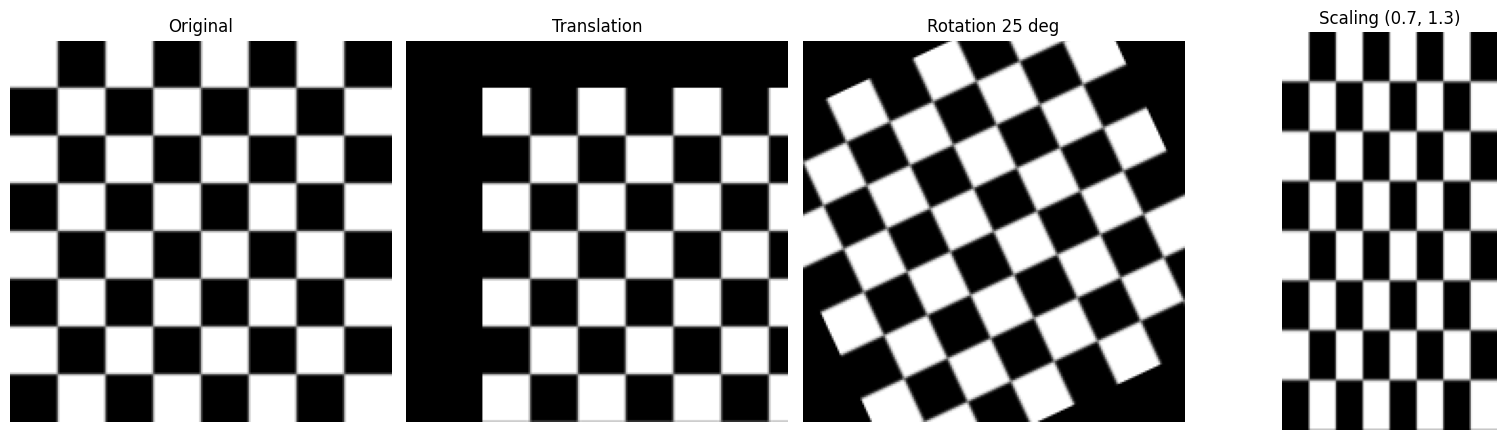

In [6]:
board = to_gray3(images["checkerboard"])

trans = p3.translate(board, tx=40, ty=25)
rot = p3.rotate(board, angle_deg=25)
scl = p3.scale_image(board, fx=0.7, fy=1.3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, im, t in zip(axes, [board, trans, rot, scl],
                      ["Original", "Translation", "Rotation 25 deg", "Scaling (0.7, 1.3)"]):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

Affine matrix:
 [[ 0.90452261  0.15075377  0.        ]
 [-0.10050251  0.8040201  30.        ]]
Homography matrix:
 [[ 4.42211055e-01 -2.72194305e-01  5.60000000e+01]
 [ 0.00000000e+00  4.01172529e-01  1.00000000e+01]
 [-0.00000000e+00 -2.72194305e-03  1.00000000e+00]]


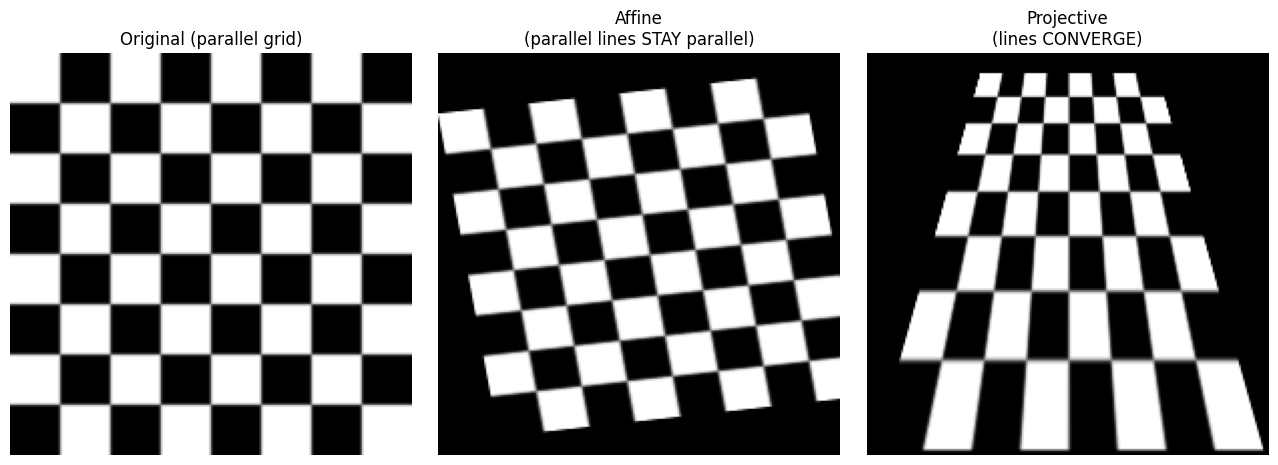

In [7]:
aff, aff_M = p3.affine_transform(board)
proj, proj_M = p3.projective_transform(board)
print("Affine matrix:\n", aff_M)
print("Homography matrix:\n", proj_M)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, im, t in zip(axes, [board, aff, proj],
                      ["Original (parallel grid)", "Affine\n(parallel lines STAY parallel)", "Projective\n(lines CONVERGE)"]):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

**Observation:** The affine checkerboard still has parallel grid lines. In the projective result, the lines converge. A projective transform is useful for perspective changes, such as correcting a photo of a page taken at an angle.

## Summary

- RGB to grayscale loses color; channel splitting and reconstruction do not.
- Low-pass filters smooth the image; high-pass filters emphasize changes and noise.
- Affine transforms preserve parallel lines; projective transforms can show perspective.

Run the three scripts in `src/` to save the figures under `outputs/`.